In [1]:
!pip install onnx onnxruntime torchvision pillow

  Obtaining dependency information for onnx from https://files.pythonhosted.org/packages/9c/3b/5146ba0a89f73c026bb468c49612bab8d005aa28155ebf06cf5f2eb8d36c/onnx-1.20.0-cp312-abi3-win_amd64.whl.metadata
  Obtaining dependency information for onnxruntime from https://files.pythonhosted.org/packages/c0/b4/569d298f9fc4d286c11c45e85d9ffa9e877af12ace98af8cab52396e8f46/onnxruntime-1.23.2-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for protobuf>=4.25.1 from https://files.pythonhosted.org/packages/64/20/4d50191997e917ae13ad0a235c8b42d8c1ab9c3e6fd455ca16d416944355/protobuf-6.33.2-cp310-abi3-win_amd64.whl.metadata
  Obtaining dependency information for ml_dtypes>=0.5.0 from https://files.pythonhosted.org/packages/f5/f0/0cfadd537c5470378b1b32bd859cf2824972174b51b873c9d95cfd7475a5/ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for coloredlogs from https://files.pythonhosted.org/packages/a7/06/3d6badcf13db419e25b07041d9c7b4a2c331d3f4e7


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from torchvision import transforms
from io import BytesIO
from urllib import request
from PIL import Image
import onnxruntime as ort
import numpy as np
import onnx

1. Output name

In [3]:
# Load the model
model_path = "hair_classifier_v1.onnx"
model = onnx.load(model_path)

# Print the output node names
output_names = [output.name for output in model.graph.output]
print("Output node names:", output_names)

Output node names: ['output']


In [4]:
def download_image(url):
    with request.urlopen(url) as resp:
        buffer = resp.read()
    stream = BytesIO(buffer)
    img = Image.open(stream)
    return img


def prepare_image(img, target_size):
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize(target_size, Image.NEAREST)
    return img

2.

2. Image size 

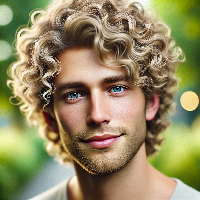

In [5]:
url = "https://habrastorage.org/webt/yf/_d/ok/yf_dokzqy3vcritme8ggnzqlvwa.jpeg"

img = download_image(url)
img = prepare_image(img, target_size=(200, 200))
img

3. First R value after pre-processing

In [6]:
preprocess = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )  # ImageNet normalization
])

# Apply the preprocessing
input_tensor = preprocess(img)

# Convert to numpy array (C x H x W)
input_array = input_tensor.numpy()

# Get the value of the first pixel in the R channel (index 0)
# input_array shape: [C, H, W] -> [0, 0, 0] = first pixel of R channel
r_channel_first_pixel_value = input_array[0, 0, 0]

print(f"Value of the first pixel in the R channel: {r_channel_first_pixel_value}")


Value of the first pixel in the R channel: -1.0732940435409546


4. Model output

In [7]:
# Add batch dimension: (1, C, H, W)
input_array_batch = np.expand_dims(input_array, axis=0)

onnx_model_path = "hair_classifier_v1.onnx"
session = ort.InferenceSession(onnx_model_path, providers=["CPUExecutionProvider"])

inputs = session.get_inputs()
outputs = session.get_outputs()

input_name = inputs[0].name
output_name = outputs[0].name

result = session.run([output_name], {input_name: input_array_batch})
predictions = result[0][0].tolist()
print("Predictions:", predictions)


Predictions: [0.09156641364097595]
